# StockSense AI – Tesla Stock Price Forecasting Using LSTM

This notebook presents a complete end-to-end machine learning workflow for forecasting Tesla (TSLA) stock prices using an LSTM neural network.

## 1. Import Libraries

The notebook starts by importing the key libraries for data collection, visualization, preprocessing, and deep learning.

In [ ]:

import importlib.util
import subprocess
import sys

required_packages = ['yfinance', 'pandas', 'matplotlib', 'seaborn', 'numpy', 'scikit-learn', 'tensorflow']
missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]

if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import tensorflow as tf
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8')
print('All required libraries are available.')

All required libraries are available.


## 2. Download Tesla Historical Data

Historical stock data is downloaded automatically from Yahoo Finance using the yFinance library.

In [16]:
ticker = 'TSLA'
data = yf.download(ticker, start='2015-01-01', end='2026-01-01', progress=False)
data = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
data.head()

Price,Open,High,Low,Close,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000
2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500
2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500
2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000
2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500


## 3. Exploratory Data Analysis (EDA)

We inspect the dataset structure, summary statistics, and missing values before modeling.

In [17]:
print('Dataset information:')
data.info()
print('\nDescriptive statistics:')
display(data.describe())
print('\nMissing values:')
display(data.isnull().sum())

# Add moving averages for analysis
data['50_MA'] = data['Close'].rolling(window=50).mean()
data['200_MA'] = data['Close'].rolling(window=200).mean()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Open, TSLA)    2766 non-null   float64
 1   (High, TSLA)    2766 non-null   float64
 2   (Low, TSLA)     2766 non-null   float64
 3   (Close, TSLA)   2766 non-null   float64
 4   (Volume, TSLA)  2766 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.7 KB

Descriptive statistics:


Price,Open,High,Low,Close,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03
mean,137.515471,140.534547,134.297418,137.488113,1.109920e+08
std,130.853659,133.687039,127.737755,130.756651,7.152193e+07
min,9.488000,10.331333,9.403333,9.578000,1.062000e+07
25%,17.825500,18.074166,17.549000,17.845167,6.769210e+07
50%,69.859333,74.100666,69.474335,73.314667,9.284585e+07
75%,241.982494,247.075005,236.662502,241.045002,1.284504e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08



Missing values:


Price   Ticker
Open    TSLA      0
High    TSLA      0
Low     TSLA      0
Close   TSLA      0
Volume  TSLA      0
dtype: int64

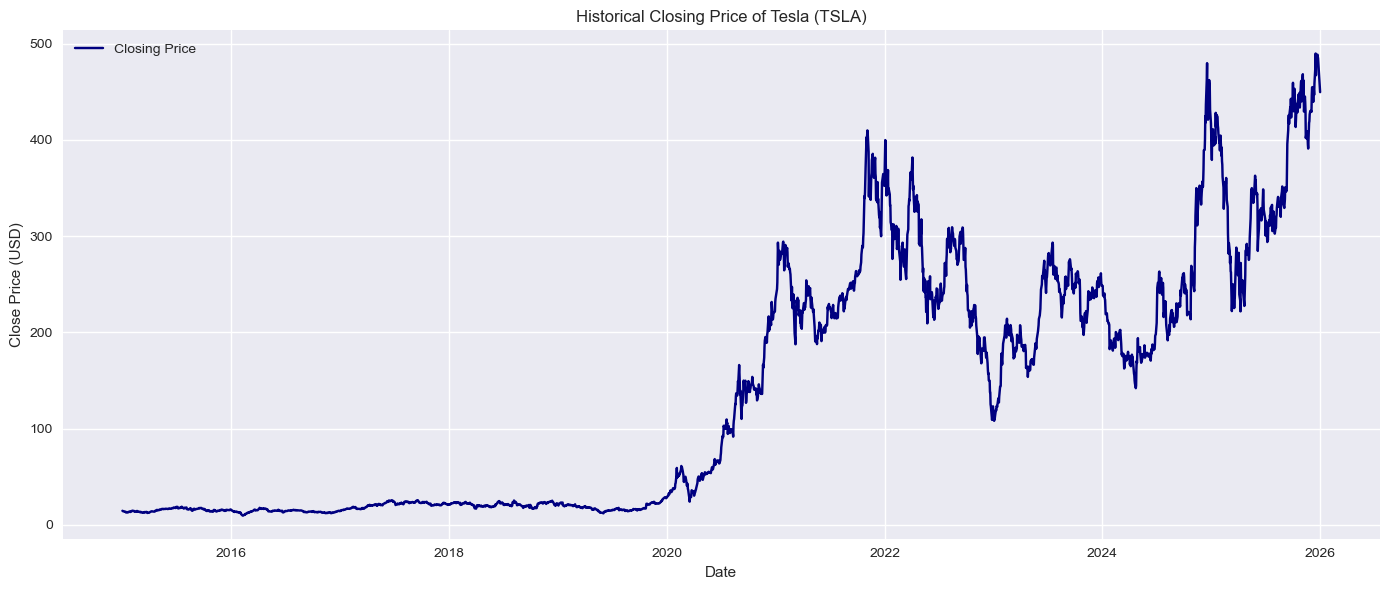

In [ ]:

plt.figure(figsize=(14, 6))
plt.plot(data['Close'], label='Closing Price', color='navy')
plt.title('Historical Closing Price of Tesla (TSLA)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

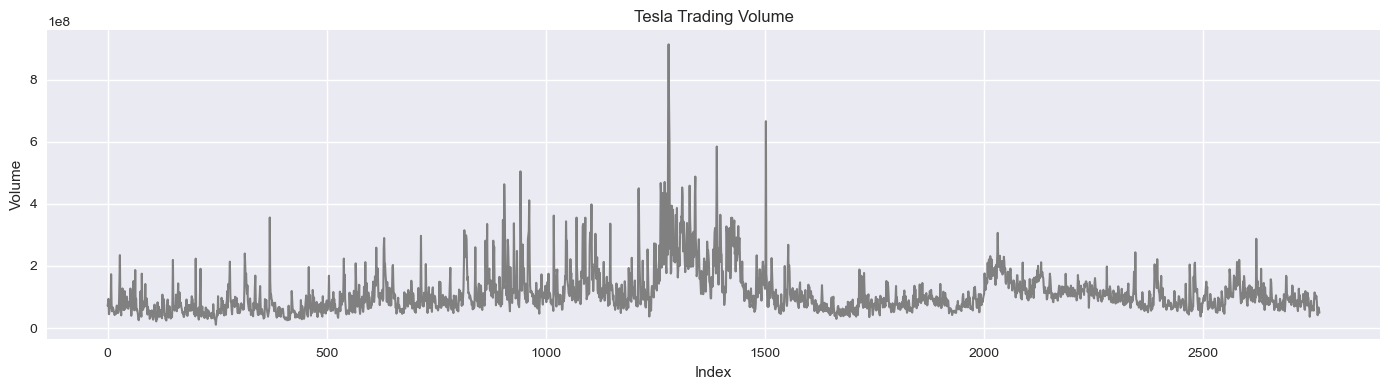

In [ ]:

plt.figure(figsize=(14, 4))
volume = data['Volume'].astype(float)
plt.plot(range(len(volume)), volume, color='gray', linewidth=1.5)
plt.title('Tesla Trading Volume')
plt.xlabel('Index')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

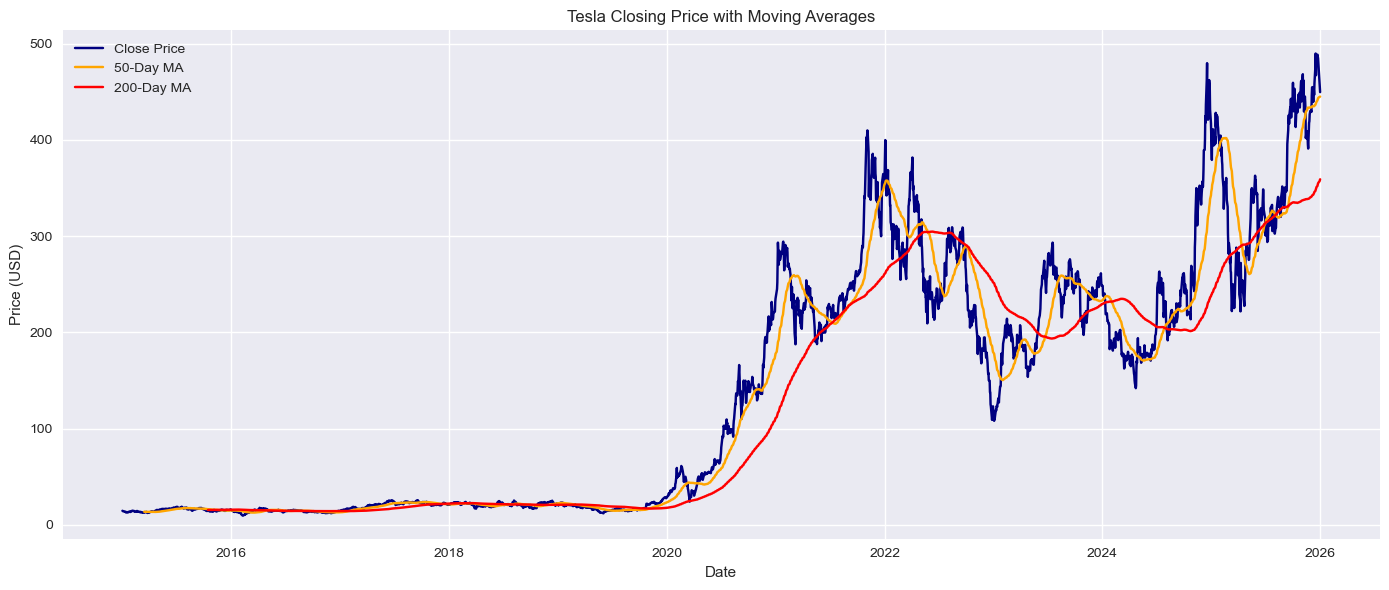

In [ ]:

plt.figure(figsize=(14, 6))
plt.plot(data['Close'], label='Close Price', color='navy')
plt.plot(data['50_MA'], label='50-Day MA', color='orange')
plt.plot(data['200_MA'], label='200-Day MA', color='red')
plt.title('Tesla Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

We focus only on the closing price, apply MinMax scaling, and create 60-day sequences for the LSTM model.

In [ ]:

close_series = data['Close'].dropna().values.reshape(-1, 1)


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_series)


def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X_full, y_full = create_sequences(scaled_close, seq_length)


train_size = int(len(X_full) * 0.8)
X_train, X_test = X_full[:train_size], X_full[train_size:]
y_train, y_test = y_full[:train_size], y_full[train_size:]


X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'Training samples: {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print(f'Test samples: {len(X_test)}')

Training samples: 1731
Validation samples: 433
Test samples: 542


## 5. Build and Train the LSTM Model

An LSTM model is created with dropout layers to reduce overfitting and improve generalization.

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0154 - val_loss: 0.0010
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0019 - val_loss: 9.1747e-04
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0016 - val_loss: 7.1946e-04
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0015 - val_loss: 8.2347e-04
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0013 - val_loss: 6.6950e-04
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0013 - val_loss: 6.9403e-04
Epoch 9/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0013 - val_loss: 6.6805e-04
Epoch 10/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0011 - val_loss: 8.4982e-04
Epoch 11/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0011 - val_loss: 9.1000e-04
Epoch 12/15
55/55 ━━━━━━━━━━━━━

## 6. Evaluate the Model

The trained model is evaluated using MAE, MSE, and RMSE on the test data.

In [ ]:
predictions_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)
actual_scaled = y_test.reshape(-1, 1)

predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(actual_scaled)

mae = mean_absolute_error(actual, predictions)
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')

MAE: 15.3891
MSE: 430.8756
RMSE: 20.7575


## 7. Visualization of Results

The notebook generates several clear charts to compare actual and predicted values, show training loss, and inspect prediction errors.

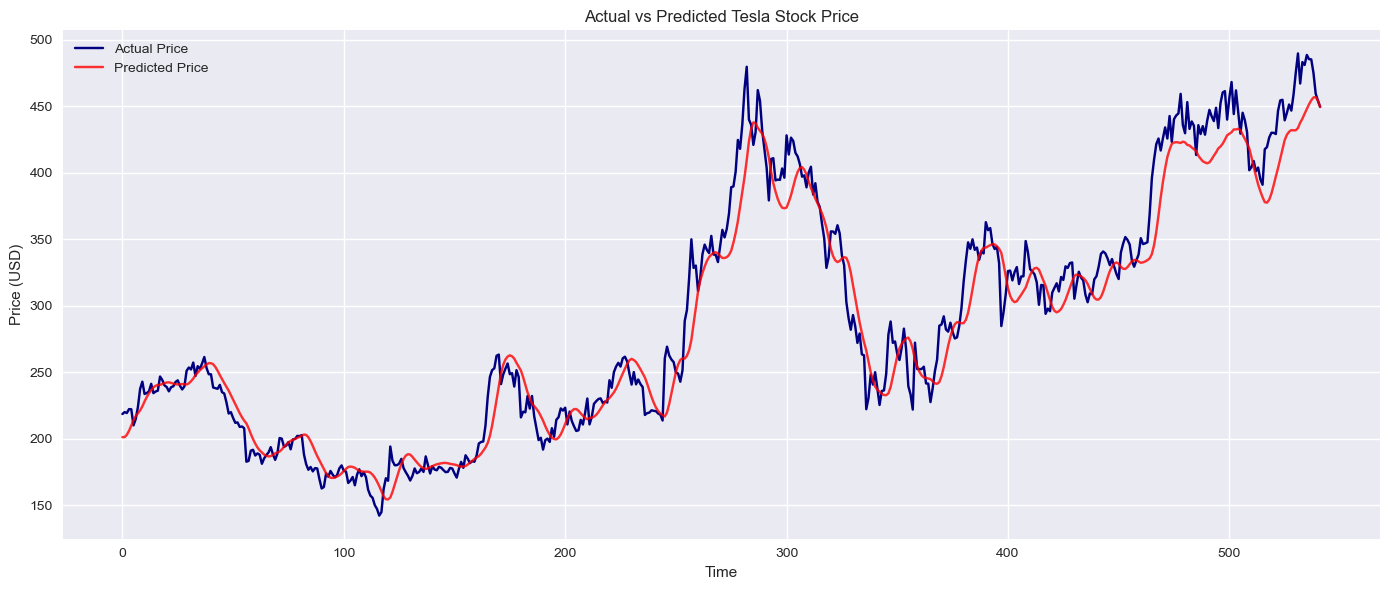

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(actual, label='Actual Price', color='navy')
plt.plot(predictions, label='Predicted Price', color='red', alpha=0.8)
plt.title('Actual vs Predicted Tesla Stock Price')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

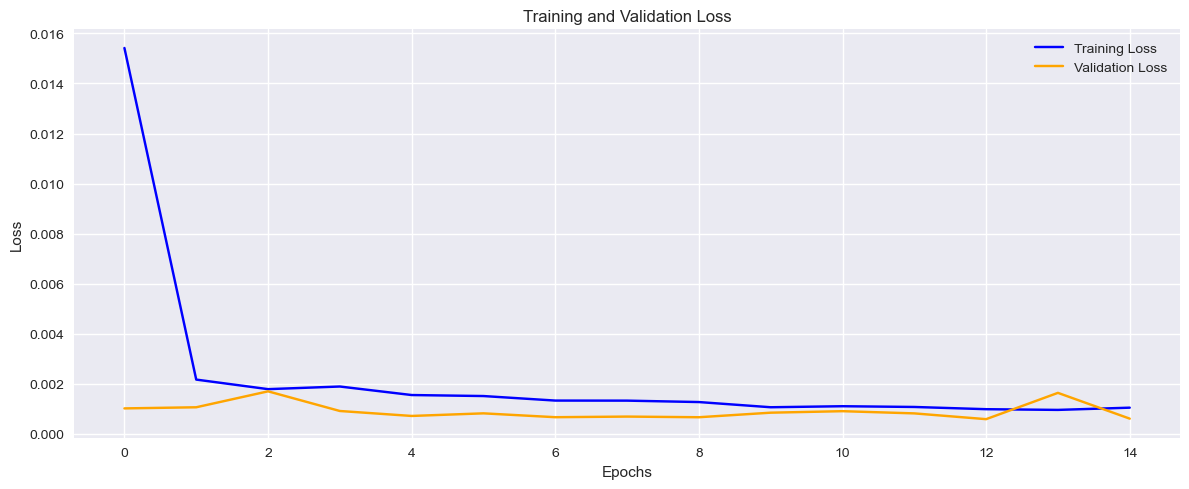

In [ ]:

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

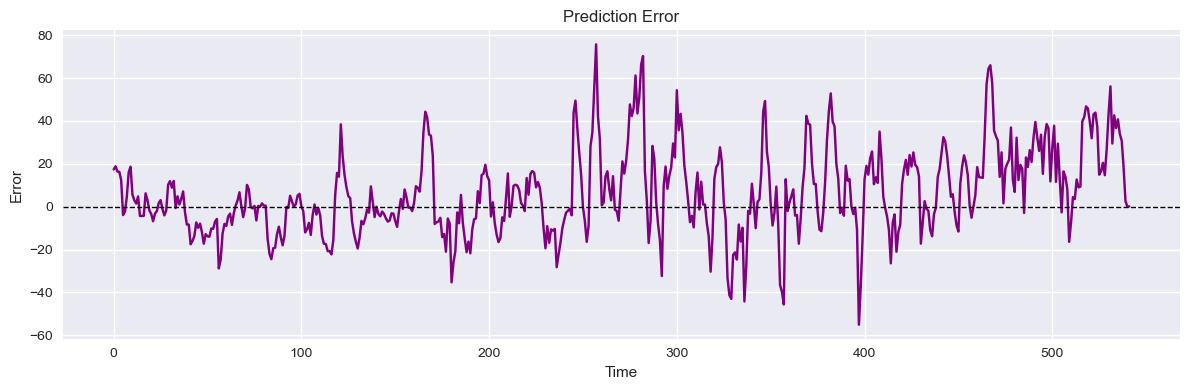

In [ ]:

errors = actual - predictions
plt.figure(figsize=(12, 4))
plt.plot(errors, color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Prediction Error')
plt.xlabel('Time')
plt.ylabel('Error')
plt.tight_layout()
plt.show()

In [ ]:

sample_predictions = pd.DataFrame({
    'Actual': np.round(actual.flatten()[:10], 2),
    'Predicted': np.round(predictions.flatten()[:10], 2)
})
sample_predictions

,Actual,Predicted
0,218.51,201.130005
1,219.96,201.100006
2,219.27,202.899994
3,222.18,205.899994
4,222.11,209.759995
5,209.98,213.899994
6,214.65,216.899994
7,223.71,219.130005
8,237.41,221.250000
9,242.84,224.199997


## 8. Save the Trained Model

The trained model is saved as a Keras file for later use in a Streamlit application.

In [29]:
model.save('lstm_model.keras')
print('Model saved successfully as lstm_model.keras')

Model saved successfully as lstm_model.keras
